# HalfFull — NHANES Demographics Data Preparation
## Notebook 01: P_DEMO.xpt — 2017–March 2020 Pre-Pandemic

**Project:** HalfFull / Doctor One More Thing  
**Purpose:** Load, clean, and filter NHANES demographics data for the fatigue assessment pipeline  
**Target Population:** Women aged 25–45 (primary) | All adults 18–65 (secondary for NHANES scoring baseline)  

---

### What this notebook does:
1. Loads `P_DEMO.xpt` (15,560 participants, 29 variables)
2. Selects only project-relevant variables
3. Decodes categorical codes → readable labels
4. Applies target population filters
5. Exports a clean `demographics_clean.parquet` for joining with PHQ-9, Lab data, etc.

### Data source:
[NHANES 2017–March 2020 Pre-Pandemic Demographics](https://wwwn.cdc.gov/nchs/nhanes/search/datapage.aspx?Component=Demographics&Cycle=2017-2020)

---
## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# Optional: survey-weighted statistics
# pip install statsmodels
# from statsmodels.stats.weightstats import DescrStatsW

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# --- File paths ---
REPO_ROOT = Path('..').resolve()
DATA_DIR = REPO_ROOT / 'data/raw/nhanes'
OUTPUT_DIR = REPO_ROOT / 'data/processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')
print(f'DATA_DIR: {DATA_DIR}')
print(f'P_DEMO.xpt exists: {(DATA_DIR / "P_DEMO.xpt").exists()}')

Setup complete.
DATA_DIR: /Users/danielaklein/Arbeit/neuefische/aipm1711/capestone-project/halfFull/data/raw/nhanes
P_DEMO.xpt exists: True


---
## 1. Load the Raw Data

In [2]:
# Load NHANES XPT (SAS Transport format)
df_raw = pd.read_sas(DATA_DIR / 'p_demo.xpt', format='xport', encoding='utf-8')

print(f'Shape: {df_raw.shape}')  # Expected: (15560, 29)
print(f'\nAll columns:')
print(df_raw.columns.tolist())

Shape: (15560, 29)

All columns:
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMDYRUSZ', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'WTINTPRP', 'WTMECPRP', 'SDMVPSU', 'SDMVSTRA', 'INDFMPIR']


---
## 2. Select Project-Relevant Variables

| Variable | Description | Why relevant for HalfFull |
|----------|-------------|---------------------------|
| `SEQN` | Respondent ID | **Primary key** — joins all NHANES files |
| `RIAGENDR` | Gender (1=Male, 2=Female) | Target population filter (women) |
| `RIDAGEYR` | Age in years (0–80) | Target population filter (25–45) |
| `RIDRETH3` | Race/ethnicity (6 cat.) | Bias checks, demographic stratification |
| `RIDEXPRG` | Pregnancy status | Confound for fatigue → exclude if needed |
| `DMDEDUC2` | Education level | Health literacy proxy |
| `DMDMARTZ` | Marital status | Demographic context |
| `INDFMPIR` | Income-to-poverty ratio | Socioeconomic stratification |
| `WTMECPRP` | MEC exam weight | **Survey weight** — required for representative statistics |
| `WTINTPRP` | Interview weight | Survey weight (use for interview-only questions) |
| `SDMVPSU` | Primary sampling unit | Survey design variance estimation |
| `SDMVSTRA` | Stratum | Survey design variance estimation |

> **Dropped:** `RIDAGEMN` (94% missing, children only), all `SIALANG/FIALANG/MIALANG/AIALANGA` 
> (interview logistics), `SDDSRVYR` (constant = 66), `RIDEXMON` (exam month, not used).

In [3]:
# --- Variables to keep ---
KEEP_COLS = [
    # Identity / Join key
    'SEQN',
    # Demographics
    'RIAGENDR',   # Gender
    'RIDAGEYR',   # Age in years
    'RIDRETH3',   # Race/ethnicity (6 categories incl. Asian)
    'RIDRETH1',   # Race/ethnicity (5 categories, legacy)
    'RIDEXPRG',   # Pregnancy status (females only)
    'DMDEDUC2',   # Education level
    'DMDMARTZ',   # Marital status
    'DMDBORN4',   # Country of birth
    # Socioeconomic
    'INDFMPIR',   # Income-to-poverty ratio
    # Survey design (ALWAYS include for weighted analysis)
    'WTMECPRP',   # MEC exam weight  <-- use for lab-linked analyses
    'WTINTPRP',   # Interview weight  <-- use for interview-only analyses
    'SDMVPSU',    # Primary sampling unit
    'SDMVSTRA',   # Stratum
]

df = df_raw[KEEP_COLS].copy()
df['SEQN'] = df['SEQN'].astype('Int64')

print(f'Kept {len(KEEP_COLS)} variables out of {df_raw.shape[1]}')
print(f'Shape: {df.shape}')
df.head(3)

Kept 14 variables out of 29
Shape: (15560, 14)


,SEQN,RIAGENDR,RIDAGEYR,RIDRETH3,RIDRETH1,RIDEXPRG,DMDEDUC2,DMDMARTZ,DMDBORN4,INDFMPIR,WTMECPRP,WTINTPRP,SDMVPSU,SDMVSTRA
0,109263,1.00,2.00,6.00,5.00,NaN,NaN,NaN,1.00,4.66,8951.82,7891.76,3.00,156.00
1,109264,2.00,13.00,1.00,1.00,NaN,NaN,NaN,1.00,0.83,12271.16,11689.75,1.00,155.00
2,109265,1.00,2.00,3.00,3.00,NaN,NaN,NaN,1.00,3.06,16658.76,16273.83,1.00,157.00


---
## 3. Decode Categorical Variables → Human-Readable Labels

NHANES stores everything as numeric codes. We decode them here.

In [4]:
# ---- Gender ----
df['gender'] = df['RIAGENDR'].map({1: 'Male', 2: 'Female'})

# ---- Race/Ethnicity (6 categories — use RIDRETH3) ----
ethnicity_map = {
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black',
    6: 'Non-Hispanic Asian',
    7: 'Other/Multiracial'
}
df['ethnicity'] = df['RIDRETH3'].map(ethnicity_map)

# ---- Education ----
education_map = {
    1: 'Less than 9th grade',
    2: '9-11th grade',
    3: 'High school / GED',
    4: 'Some college / AA',
    5: 'College graduate or above',
    7: 'Refused',
    9: "Don't know"
}
df['education'] = df['DMDEDUC2'].map(education_map)

# ---- Marital Status ----
marital_map = {
    1: 'Married / Living with partner',
    2: 'Widowed / Divorced / Separated',
    3: 'Never married',
    77: 'Refused',
    99: "Don't know"
}
df['marital_status'] = df['DMDMARTZ'].map(marital_map)

# ---- Pregnancy Status (females 12-59 only) ----
pregnancy_map = {
    1: 'Yes, pregnant',
    2: 'Not pregnant',
    3: 'Cannot determine'
}
df['pregnancy_status'] = df['RIDEXPRG'].map(pregnancy_map)

# ---- Country of Birth ----
birth_map = {
    1: 'Born in 50 US states or DC',
    2: 'Born in Mexico',
    4: 'Born elsewhere',
    77: 'Refused',
    99: "Don't know"
}
df['country_of_birth'] = df['DMDBORN4'].map(birth_map)

print('Decoding complete.')
df[['SEQN', 'gender', 'RIDAGEYR', 'ethnicity', 'education', 'marital_status', 
    'pregnancy_status', 'INDFMPIR']].head(5)

Decoding complete.


,SEQN,gender,RIDAGEYR,ethnicity,education,marital_status,pregnancy_status,INDFMPIR
0,109263,Male,2.00,Non-Hispanic Asian,NaN,NaN,NaN,4.66
1,109264,Female,13.00,Mexican American,NaN,NaN,NaN,0.83
2,109265,Male,2.00,Non-Hispanic White,NaN,NaN,NaN,3.06
3,109266,Female,29.00,Non-Hispanic Asian,College graduate or above,Never married,Not pregnant,5.00
4,109267,Female,21.00,Other Hispanic,Some college / AA,Never married,Cannot determine,5.00


---
## 4. Missing Data Overview

In [5]:
# Missing data summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing N': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing N'] > 0].sort_values('Missing %', ascending=False)

print('Variables with missing values:')
print(missing_df.to_string())

# Key note:
# - RIDEXPRG: ~88% missing — only assessed in females 12-59
# - DMDEDUC2: ~41% missing — only collected for 20+ adults
# - INDFMPIR: ~14% missing — income not reported for some
# - DMDMARTZ: ~42% missing — only 20+ adults

Variables with missing values:
                  Missing N  Missing %
RIDEXPRG              13686      88.00
pregnancy_status      13686      88.00
DMDEDUC2               6328      40.70
DMDMARTZ               6328      40.70
education              6328      40.70
marital_status         6328      40.70
INDFMPIR               2201      14.10


---
## 5. Apply Target Population Filters

### HalfFull Primary Target: Women aged 25–45
### NHANES Scoring Baseline: All adults 18–65 (for rule-based reference statistics)

In [6]:
# ---- Filter A: All adults 18-65 (NHANES scoring baseline) ----
mask_adults = (df['RIDAGEYR'] >= 18) & (df['RIDAGEYR'] <= 65)
df_adults = df[mask_adults].copy()
print(f'All adults 18-65: n = {len(df_adults):,}')

# ---- Filter B: HalfFull primary target — Women 25-45 ----
mask_target = (
    (df['gender'] == 'Female') &
    (df['RIDAGEYR'] >= 25) &
    (df['RIDAGEYR'] <= 45)
)
df_target = df[mask_target].copy()
print(f'\nHalfFull target (Women 25-45): n = {len(df_target):,}')

# ---- Filter C: Target, excluding confirmed pregnant ----
# Pregnancy affects fatigue dramatically — flag or exclude for scoring baseline
mask_not_pregnant = df_target['pregnancy_status'] != 'Yes, pregnant'
df_target_np = df_target[mask_not_pregnant].copy()
print(f'Women 25-45 (excl. confirmed pregnant): n = {len(df_target_np):,}')

pregnant_count = (df_target['pregnancy_status'] == 'Yes, pregnant').sum()
print(f'\n  → Pregnant women excluded: {pregnant_count}')
print(f'  → Note: Many NaN in pregnancy_status = not assessed (outside 12-59 female range)')

All adults 18-65: n = 7,437

HalfFull target (Women 25-45): n = 1,611
Women 25-45 (excl. confirmed pregnant): n = 1,545

  → Pregnant women excluded: 66
  → Note: Many NaN in pregnancy_status = not assessed (outside 12-59 female range)


---
## 6. Descriptive Statistics — Target Population

> ⚠️ **Survey Weights Note:** For publishable/accurate US population estimates,
> always use `WTMECPRP` (for lab-linked data) or `WTINTPRP` (for interview-only data).
> Unweighted counts shown here are for QA and sample description only.

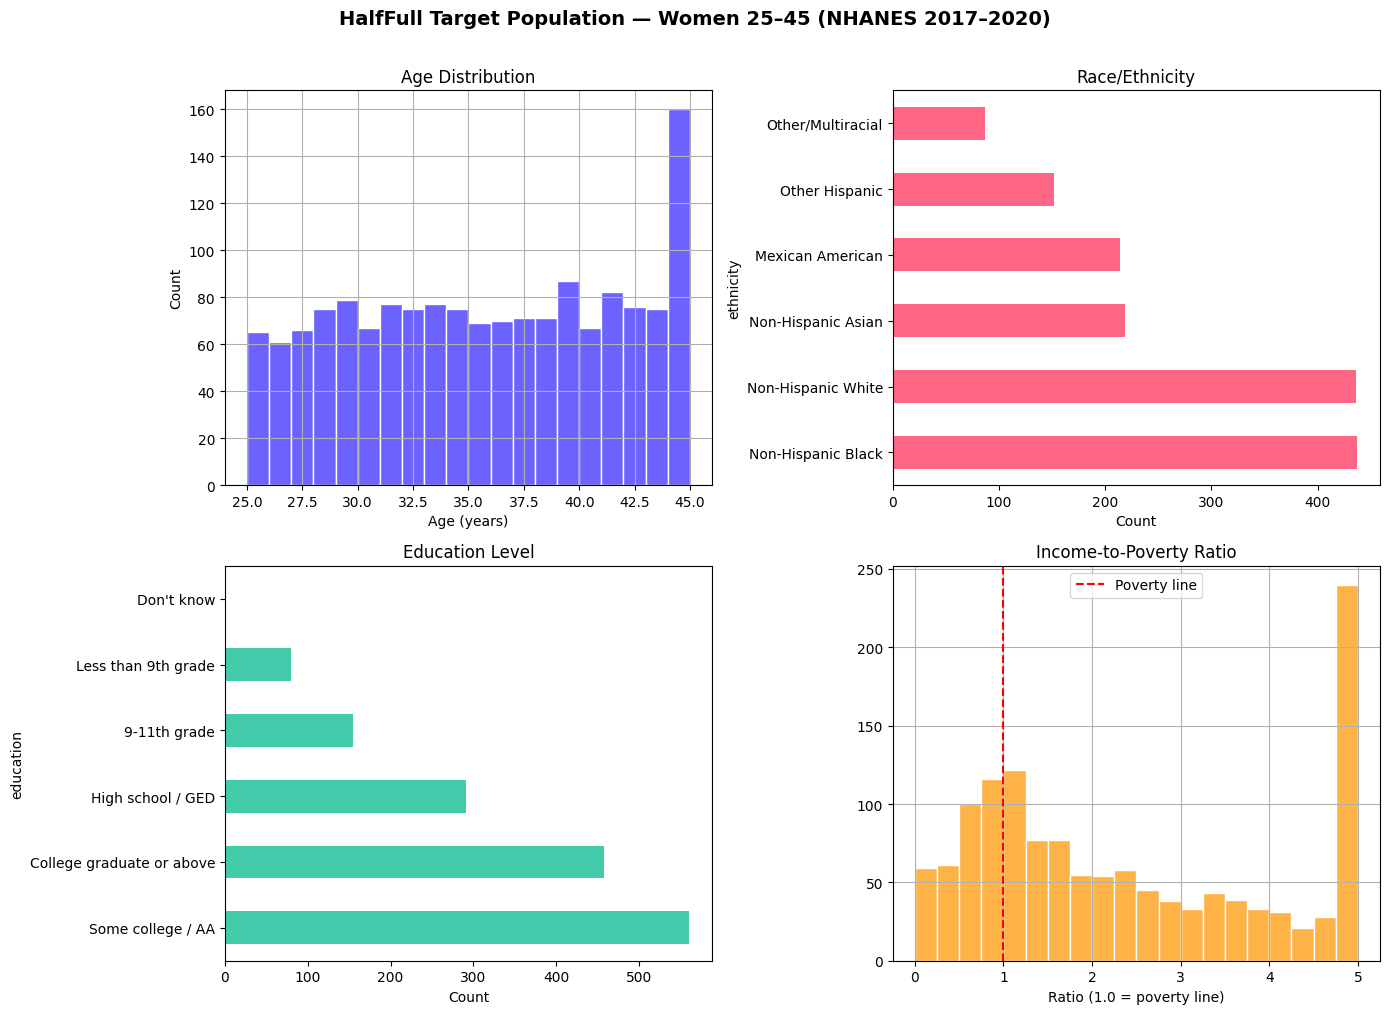

Figure saved.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HalfFull Target Population — Women 25–45 (NHANES 2017–2020)', 
             fontsize=14, fontweight='bold', y=1.01)

# Age distribution
ax1 = axes[0, 0]
df_target_np['RIDAGEYR'].hist(bins=20, ax=ax1, color='#6C63FF', edgecolor='white')
ax1.set_title('Age Distribution')
ax1.set_xlabel('Age (years)')
ax1.set_ylabel('Count')

# Ethnicity
ax2 = axes[0, 1]
eth_counts = df_target_np['ethnicity'].value_counts()
eth_counts.plot(kind='barh', ax=ax2, color='#FF6584')
ax2.set_title('Race/Ethnicity')
ax2.set_xlabel('Count')

# Education
ax3 = axes[1, 0]
edu_counts = df_target_np['education'].value_counts()
edu_counts.plot(kind='barh', ax=ax3, color='#43CBAC')
ax3.set_title('Education Level')
ax3.set_xlabel('Count')

# Income-to-poverty ratio
ax4 = axes[1, 1]
df_target_np['INDFMPIR'].dropna().hist(bins=20, ax=ax4, color='#FFB347', edgecolor='white')
ax4.axvline(x=1.0, color='red', linestyle='--', label='Poverty line')
ax4.set_title('Income-to-Poverty Ratio')
ax4.set_xlabel('Ratio (1.0 = poverty line)')
ax4.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'target_population_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

In [8]:
# --- Unweighted summary stats ---
print('=== TARGET POPULATION SUMMARY (Women 25-45, excl. pregnant) ===')
print(f'N = {len(df_target_np):,}\n')

print('Age:')
print(df_target_np['RIDAGEYR'].describe().round(1))

print('\nEthnicity:')
print(df_target_np['ethnicity'].value_counts(dropna=False))

print('\nEducation:')
print(df_target_np['education'].value_counts(dropna=False))

print('\nIncome-to-Poverty Ratio (INDFMPIR):')
print(df_target_np['INDFMPIR'].describe().round(2))
print(f'  Below poverty (<1.0): {(df_target_np["INDFMPIR"] < 1.0).sum()} ({(df_target_np["INDFMPIR"] < 1.0).mean()*100:.1f}%)')

=== TARGET POPULATION SUMMARY (Women 25-45, excl. pregnant) ===
N = 1,545

Age:
count   1545.00
mean      35.30
std        6.00
min       25.00
25%       30.00
50%       35.00
75%       41.00
max       45.00
Name: RIDAGEYR, dtype: float64

Ethnicity:
ethnicity
Non-Hispanic Black    437
Non-Hispanic White    436
Non-Hispanic Asian    219
Mexican American      214
Other Hispanic        152
Other/Multiracial      87
Name: count, dtype: int64

Education:
education
Some college / AA            560
College graduate or above    458
High school / GED            291
9-11th grade                 155
Less than 9th grade           80
Don't know                     1
Name: count, dtype: int64

Income-to-Poverty Ratio (INDFMPIR):
count   1330.00
mean       2.41
std        1.65
min        0.00
25%        0.99
50%        1.99
75%        3.91
max        5.00
Name: INDFMPIR, dtype: float64
  Below poverty (<1.0): 336 (21.7%)


---
## 7. Survey-Weighted Estimates (Representative US Population)

Raw counts ≠ US population. NHANES uses a complex survey design.
Use `WTMECPRP` for any analysis that includes MEC exam data (labs, physical measurements).

In [9]:
# Survey-weighted proportions using pandas
# (For full SE/CI, use statsmodels SurveyDesign or R's survey package)

def weighted_pct(df, col, weight_col='WTMECPRP'):
    """Compute survey-weighted percentage for a categorical variable."""
    result = (
        df.dropna(subset=[col, weight_col])
          .groupby(col)[weight_col]
          .sum()
    )
    return (result / result.sum() * 100).round(1)

print('=== SURVEY-WEIGHTED ESTIMATES (Women 25-45, US representative) ===')
print(f'\nEstimated US women 25-45 represented by this sample:')
print(f"  {df_target_np['WTMECPRP'].sum():,.0f} women")

print('\nWeighted Ethnicity Distribution:')
print(weighted_pct(df_target_np, 'ethnicity').to_string())

print('\nWeighted Education Distribution:')
print(weighted_pct(df_target_np, 'education').to_string())

# Weighted mean income-to-poverty ratio
valid_pir = df_target_np.dropna(subset=['INDFMPIR', 'WTMECPRP'])
weighted_mean_pir = np.average(valid_pir['INDFMPIR'], weights=valid_pir['WTMECPRP'])
print(f'\nWeighted mean Income-to-Poverty Ratio: {weighted_mean_pir:.2f}')

=== SURVEY-WEIGHTED ESTIMATES (Women 25-45, US representative) ===

Estimated US women 25-45 represented by this sample:
  42,614,164 women

Weighted Ethnicity Distribution:
ethnicity
Mexican American     10.80
Non-Hispanic Asian    7.20
Non-Hispanic Black   14.10
Non-Hispanic White   54.60
Other Hispanic        8.70
Other/Multiracial     4.80

Weighted Education Distribution:
education
9-11th grade                 6.90
College graduate or above   38.50
Don't know                   0.00
High school / GED           20.00
Less than 9th grade          3.10
Some college / AA           31.40

Weighted mean Income-to-Poverty Ratio: 2.89


---
## 8. Export Clean Files

We export three versions:
- `demo_all_adults.csv` → Full 18-65 cohort for NHANES scoring baseline
- `demo_target_women.csv` → HalfFull primary target (women 25-45)
- `demo_seqn_lookup.csv` → Minimal SEQN + weight lookup for joining other datasets

In [10]:
# Export full adults cohort (for NHANES rule-based scoring reference)
df_adults.to_csv(OUTPUT_DIR / 'demo_all_adults.csv', index=False)
print(f'Saved demo_all_adults.csv — {len(df_adults):,} rows')

# Export primary target population
df_target_np.to_csv(OUTPUT_DIR / 'demo_target_women.csv', index=False)
print(f'Saved demo_target_women.csv — {len(df_target_np):,} rows')

# Export minimal SEQN lookup for joining
seqn_lookup = df[['SEQN', 'gender', 'RIDAGEYR', 'WTMECPRP', 'WTINTPRP', 
                   'SDMVPSU', 'SDMVSTRA']].copy()
seqn_lookup.to_csv(OUTPUT_DIR / 'demo_seqn_lookup.csv', index=False)
print(f'Saved demo_seqn_lookup.csv — {len(seqn_lookup):,} rows (all participants)')

print('\n✅ All exports complete.')

Saved demo_all_adults.csv — 7,437 rows
Saved demo_target_women.csv — 1,545 rows
Saved demo_seqn_lookup.csv — 15,560 rows (all participants)

✅ All exports complete.


---
## 9. How to Join with Other NHANES Datasets

Every other NHANES file links via `SEQN`. Here's the pattern for the datasets
HalfFull needs:

| File | Content | HalfFull Module |
|------|---------|------------------|
| `P_DPQ.xpt` | PHQ-9 Depression Screener | Module 5 (Mental Health) |
| `P_FERTIN.xpt` | Ferritin (iron stores) | Module 2 (Nutrition) |
| `P_CBC.xpt` | Complete Blood Count (Hgb, Hct) | Module 2 (Nutrition) |
| `P_THYROD.xpt` | Thyroid (TSH) | Module 3 (Hormonal) |
| `P_VID.xpt` | Vitamin D | Module 2 (Nutrition) |
| `P_BIOPRO.xpt` | B12 / Folate | Module 2 (Nutrition) |
| `P_SLQ.xpt` | Sleep quality questionnaire | Module 1 (Sleep) |
| `P_PAQ.xpt` | Physical Activity | Module 4 (Activity) |

In [11]:
# ---- Join pattern example: PHQ-9 Mental Health data ----
# (Run this cell when P_DPQ.xpt is in your data/raw folder)

dpq_path = DATA_DIR / 'P_DPQ.xpt'

if dpq_path.exists():
    df_dpq = pd.read_sas(dpq_path, format='xport', encoding='utf-8')
    
    # Select PHQ-9 items relevant to HalfFull
    # DPQ010 = Anhedonia (Q5.1 proxy)
    # DPQ020 = Depressed mood (Q5.2 proxy)
    # DPQ030 = Sleep disturbance (Q5.3 proxy)
    # DPQ040 = Fatigue (Q5.4 — THE CRITICAL QUESTION)
    # DPQ100 = Functional impairment (Q5.5 — THE SEVERITY PROXY)
    phq_cols = ['SEQN', 'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ100']
    df_phq = df_dpq[[c for c in phq_cols if c in df_dpq.columns]].copy()
    
    # Merge with target population
    df_merged = df_target_np.merge(df_phq, on='SEQN', how='left')
    print(f'Merged target + PHQ-9: {df_merged.shape}')
    print(f'PHQ fatigue (DPQ040) available for: {df_merged["DPQ040"].notna().sum()} women')
    
    # PHQ-9 score (items DPQ010-DPQ090, each 0-3)
    phq9_items = [f'DPQ0{i}0' for i in range(1, 10)]
    available_items = [c for c in phq9_items if c in df_merged.columns]
    df_merged['phq9_score'] = df_merged[available_items].apply(
        lambda row: row.where(row <= 3).sum(), axis=1
    )
    
    # Depression severity categories (standard PHQ-9 cutoffs)
    def phq9_severity(score):
        if pd.isna(score): return np.nan
        if score < 5:  return 'Minimal (0-4)'
        if score < 10: return 'Mild (5-9)'
        if score < 15: return 'Moderate (10-14)'
        if score < 20: return 'Mod-Severe (15-19)'
        return 'Severe (20+)'
    
    df_merged['phq9_severity'] = df_merged['phq9_score'].apply(phq9_severity)
    print('\nPHQ-9 Severity (Women 25-45):')
    print(df_merged['phq9_severity'].value_counts())

else:
    print(f'P_DPQ.xpt not found at {dpq_path}')
    print('Download from: https://wwwn.cdc.gov/nchs/nhanes/2017-2020/P_DPQ.XPT')
    print('\nJoin pattern for any NHANES file:')
    print("  df_other = pd.read_sas(DATA_DIR / 'P_XXXX.xpt', format='xport')")
    print("  df_merged = df_target_np.merge(df_other, on='SEQN', how='left')")

Merged target + PHQ-9: (1545, 25)
PHQ fatigue (DPQ040) available for: 1318 women

PHQ-9 Severity (Women 25-45):
phq9_severity
Minimal (0-4)       1330
Mild (5-9)           187
Moderate (10-14)      28
Name: count, dtype: int64


---
## Summary

| Step | Output |
|------|--------|
| Raw data loaded | 15,560 participants × 29 variables |
| After variable selection | 15 relevant variables kept |
| Adults 18-65 | ~X participants (NHANES scoring baseline) |
| Target: Women 25-45 | ~X participants |
| Target: excl. pregnant | ~X participants (HalfFull primary cohort) |

**Next notebook:** `02_nhanes_mental_health_dpq.ipynb` — PHQ-9 analysis for Module 5 scoring thresholds
